In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

In [3]:
train_data = datasets.CIFAR100(root='./data', train=True,  download=True, transform=train_transform)
test_data  = datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 169M/169M [51:39<00:00, 54.5kB/s]


In [4]:
train = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2)
test  = DataLoader(test_data,  batch_size=128, shuffle=False, num_workers=2)

In [5]:
classes = train_data.classes
print(classes)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

In [6]:
len(classes)

100

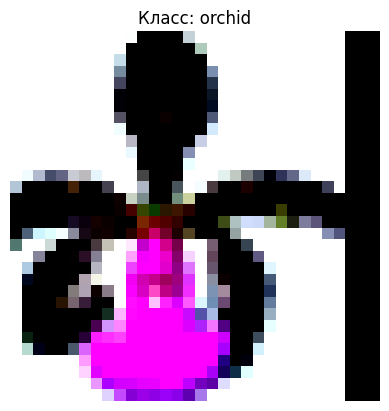

In [7]:
image, label = next(iter(train))
plt.imshow(image[0].permute(1, 2, 0))
plt.title(f'Класс: {classes[label[0]]}')
plt.axis('off')
plt.savefig('test1')
plt.show()

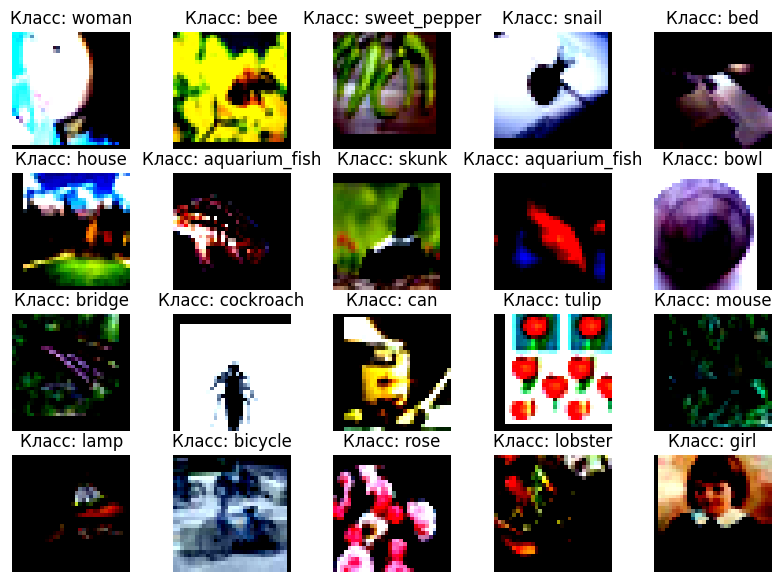

In [8]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Класс: {classes[label[i]]}')
    plt.axis('off')
plt.subplots_adjust(top=0.65)
plt.savefig('test2')
plt.show()

In [9]:
classes = train_data.classes

class Cifar100Classification(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32 → 16
            nn.Dropout2d(0.1),

            # Блок 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16 → 8
            nn.Dropout2d(0.2),

            # Блок 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 8 → 4
            nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
model  = Cifar100Classification().to(device)

In [12]:
loss_fn   = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

In [19]:
for epoch in range(100):
    model.train()
    total_loss = 0

    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f'Эпоха: {epoch + 1:>2} | Loss: {total_loss:.2f} | LR: {scheduler.get_last_lr()[0]:.6f}')

Эпоха:  1 | Loss: 637.39 | LR: 0.000232
Эпоха:  2 | Loss: 634.88 | LR: 0.000223
Эпоха:  3 | Loss: 633.43 | LR: 0.000215
Эпоха:  4 | Loss: 630.74 | LR: 0.000206
Эпоха:  5 | Loss: 627.05 | LR: 0.000198
Эпоха:  6 | Loss: 625.70 | LR: 0.000189
Эпоха:  7 | Loss: 625.50 | LR: 0.000181
Эпоха:  8 | Loss: 623.27 | LR: 0.000173
Эпоха:  9 | Loss: 620.09 | LR: 0.000165
Эпоха: 10 | Loss: 619.88 | LR: 0.000158
Эпоха: 11 | Loss: 616.94 | LR: 0.000150
Эпоха: 12 | Loss: 615.86 | LR: 0.000143
Эпоха: 13 | Loss: 613.88 | LR: 0.000136
Эпоха: 14 | Loss: 609.68 | LR: 0.000128
Эпоха: 15 | Loss: 609.42 | LR: 0.000122
Эпоха: 16 | Loss: 606.62 | LR: 0.000115
Эпоха: 17 | Loss: 604.92 | LR: 0.000108
Эпоха: 18 | Loss: 603.40 | LR: 0.000102
Эпоха: 19 | Loss: 601.82 | LR: 0.000095
Эпоха: 20 | Loss: 601.97 | LR: 0.000089
Эпоха: 21 | Loss: 596.38 | LR: 0.000084
Эпоха: 22 | Loss: 595.87 | LR: 0.000078
Эпоха: 23 | Loss: 594.86 | LR: 0.000072
Эпоха: 24 | Loss: 594.57 | LR: 0.000067
Эпоха: 25 | Loss: 593.12 | LR: 0.000062


In [20]:
model.eval()
correct = total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        prediction = torch.argmax(model(x_batch), dim=1)
        total   += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

print(f'Точность: {correct * 100 / total:.2f}%')

Точность: 72.59%


In [21]:
from google.colab import files

torch.save(model.state_dict(), 'model_CIFAR_100.pth')

files.download('model_CIFAR_100.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>